## Analyze connected components

In [1]:
library(tidyverse)
components <- read_csv(
    "networks/results/connected_components.csv"
)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   4.0.3     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
New names:
• `` -> `...1`
Rows: 10 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (4): ...1, Threshold, Connected_components, Largest_component

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [2]:
components

...1,Threshold,Connected_components,Largest_component
<dbl>,<dbl>,<dbl>,<dbl>
0,0.1500000,89,25788
1,0.1888889,665,25179
2,0.2277778,2856,22794
3,0.2666667,7507,17347
4,0.3055556,13298,9960
5,0.3444444,18305,2971
6,0.3833333,21486,193
7,0.4222222,23366,49
8,0.4611111,24431,30


## Degree distribution of papers in the networks

In [13]:
library(tidyverse)
degrees <- read_csv(
    "networks/results/degree_distribution.csv"
)

New names:
• `` -> `...1`
Rows: 25877 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Topic
dbl (2): ...1, Degree

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


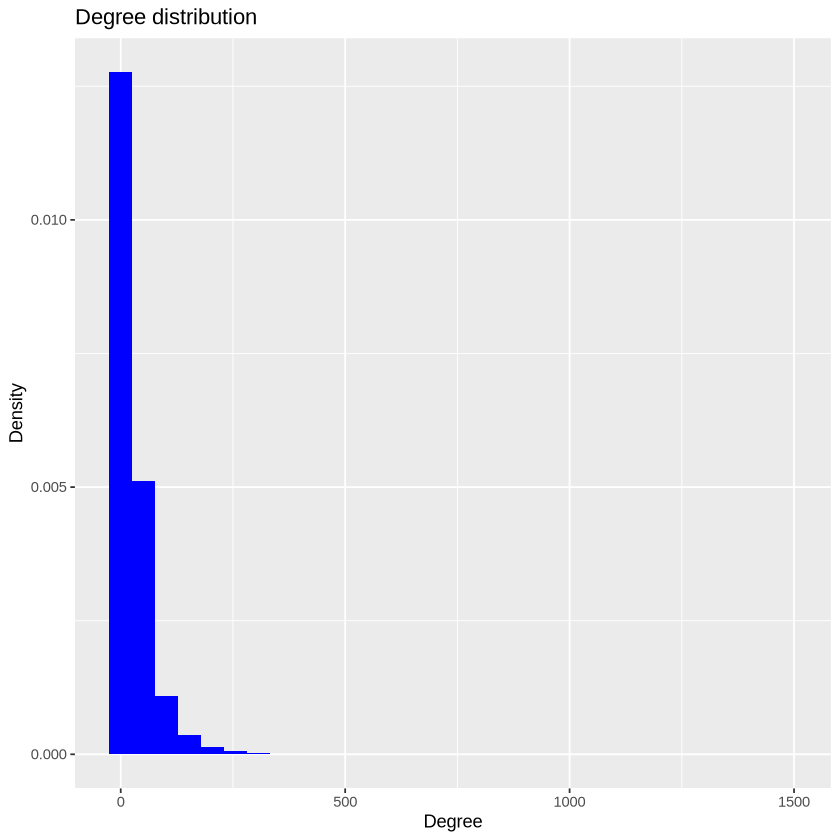

In [25]:
ggplot(data = degrees, aes(x = Degree)) +
    geom_histogram(bins = 30, fill = "blue", aes(y = after_stat(density))) +
    labs(title = "Degree distribution", x = "Degree", y = "Density")

Degree distribution looks like a power law, but of course this needs to be verified. Certainly we don't have a random network.

## Analyze degrees of nodes

In [16]:
#create a unique dataset with the papers and their degree (and topic)
all_papers <- read_csv(
    "data/all_papers.csv"
)
all_data <- bind_cols(all_papers, degrees)

New names:
• `` -> `...1`
Rows: 25877 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): authors, title, abstract, primary_cathegory, secondary_cathegory
dbl (2): ...1, paper

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `...1` -> `...8`


In [ ]:
all_data %>%
    select(c("paper", "title", "primary_cathegory", "secondary_cathegory", "Degree", "Topic")) %>%
    arrange(desc(Degree))

OLD COMMENT FOR OLD NETWORK

For what we can see, the papers with the highest degree are those with a short abstract, or written in another language (typically Spanish). Since they don't have much words in common with the other papers, their distance tends to 0, so they have a lot of links. Then I need to check two roads:

1) Maybe we made an error: it is better to put a link between papers with distance higher than a certain value, meaning that they have a lot of words in common
2) If the method above does not work, try to remove the papers with the highest degrees, and study the remaining network (hoping that it clusters the topics).

Probably the best solution is to try both ways.

In [21]:
mean(all_data$Degree)
median(all_data$Degree)

[1] 29.71828

[1] 15

The significative difference between mean and median makes it easy to think that we are not in front of a symmetric distribution, so it is another proof against the random network hypothesis

## Plot degree versus clustering coefficient/eigenvector centrality

In [13]:
library(tidyverse)
centrality_measures <- read_csv(
    "networks/results/centrality_measures.csv"
)

New names:
• `` -> `...1`
Rows: 25877 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Topic
dbl (4): ...1, Degree, Clustering_coefficient, Eigenvector_centrality

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [2]:
colnames(centrality_measures)

[1] "...1"                   "Degree"                 "Clustering_coefficient"
[4] "Eigenvector_centrality" "Topic"

In [ ]:
#centrality_measures <- centrality_measures %>%
    #filter(Degree <= 100)

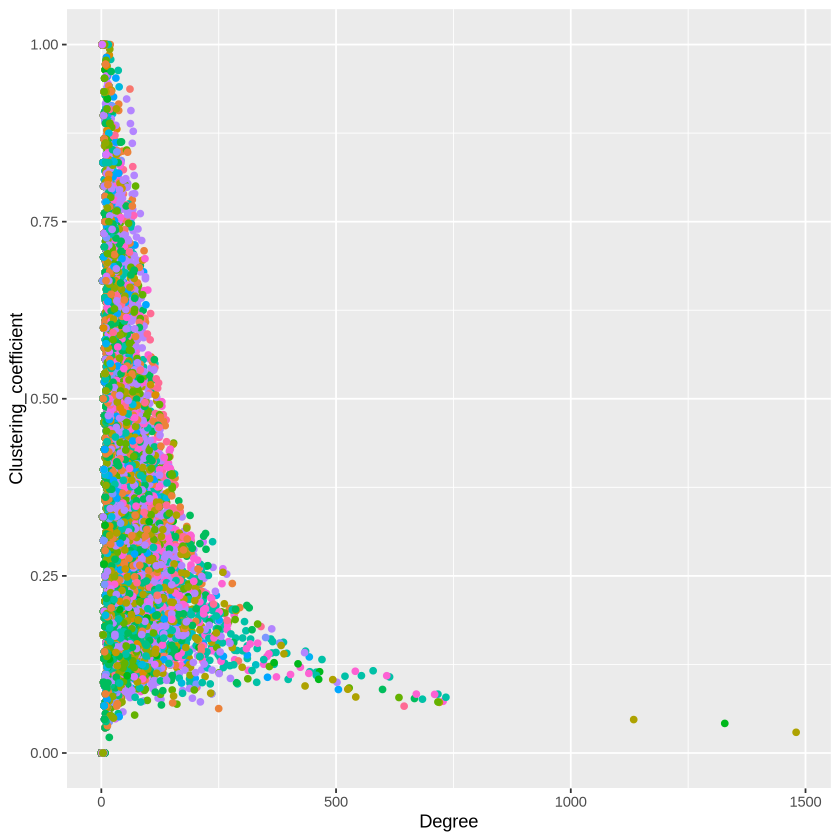

In [14]:
ggplot(data = centrality_measures, aes(x = Degree, y = Clustering_coefficient, color = Topic)) +
    geom_point() +
    theme(legend.position = "none")

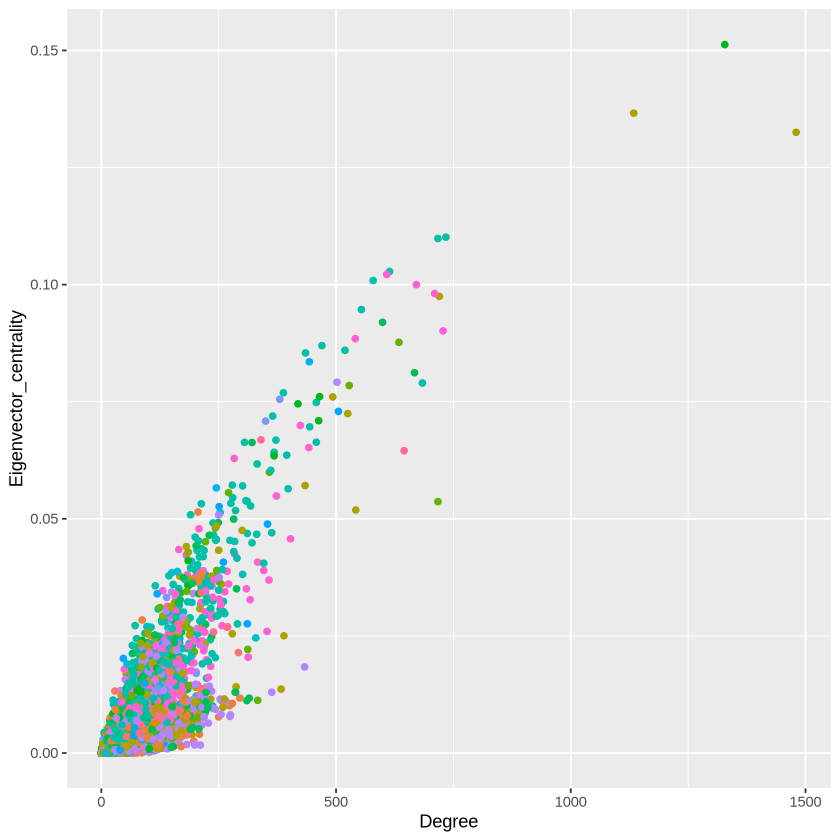

In [15]:
ggplot(data = centrality_measures, aes(x = Degree, y = Eigenvector_centrality, color = Topic)) +
    geom_point() +
    theme(legend.position = "none")

## Comparison with random network

In [1]:
library(tidyverse)
centrality_measures <- read_csv(
    "networks/results/random_network/centrality_measures.csv"
)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   4.0.3     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
New names:
• `` -> `...1`
Rows: 25877 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Topic
dbl (4): ...1, Degree, Clustering_coefficient, Eigenvector_centrality

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


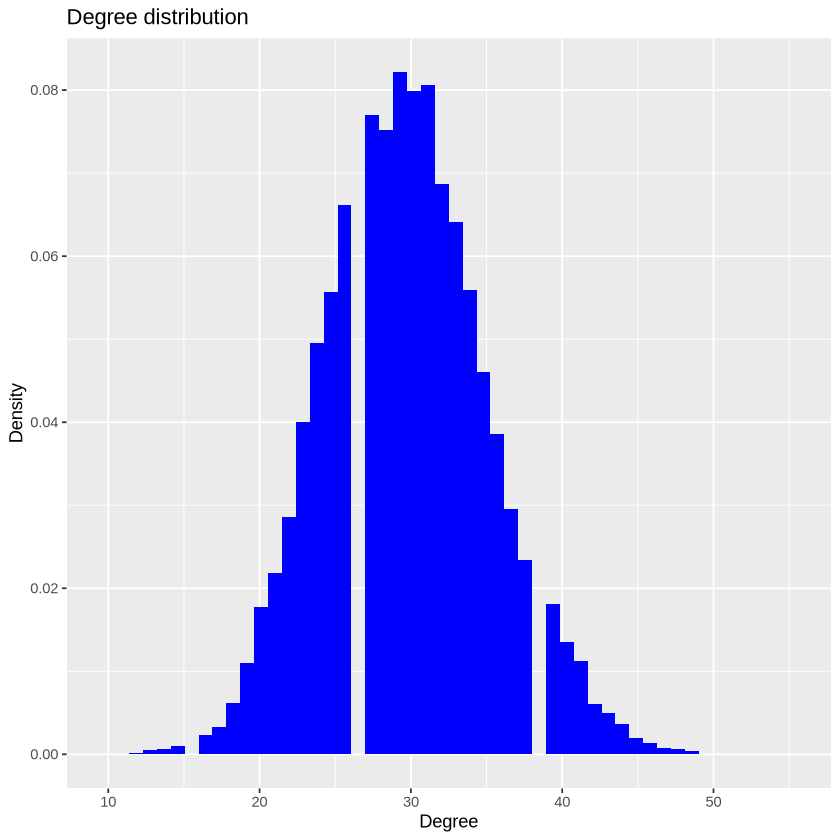

In [8]:
#degree distribution
ggplot(data = centrality_measures, aes(x = Degree)) +
    geom_histogram(bins = 50, fill = "blue", aes(y = after_stat(density))) +
    labs(title = "Degree distribution", x = "Degree", y = "Density")

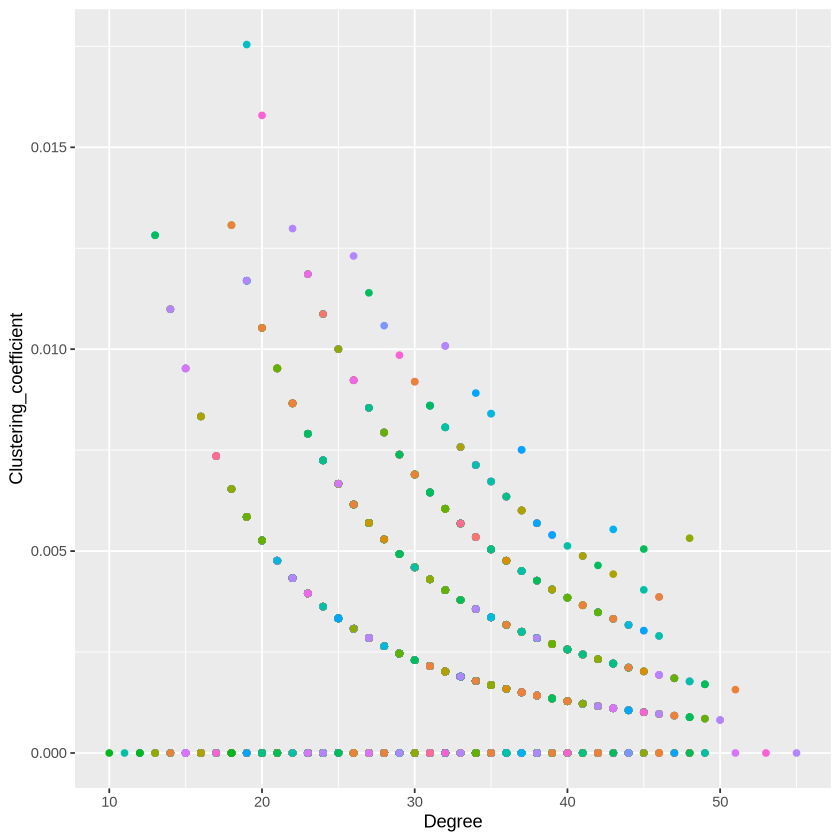

In [2]:
ggplot(data = centrality_measures, aes(x = Degree, y = Clustering_coefficient, color = Topic)) +
    geom_point() +
    theme(legend.position = "none")

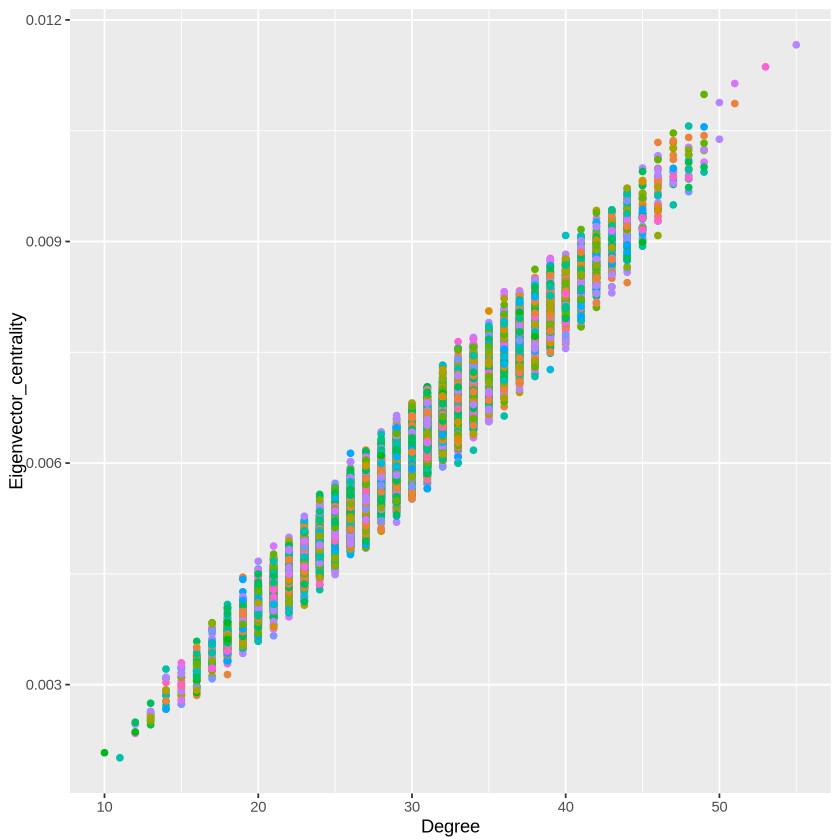

In [9]:
ggplot(data = centrality_measures, aes(x = Degree, y = Eigenvector_centrality, color = Topic)) +
    geom_point() +
    theme(legend.position = "none")

## Comparison with scale free